# Capstone B — TeleConnect: Customer Churn Analysis
**Python for Full Stack Data Science with AI & Generative AI · Naresh IT · Lead Trainer: Ajit Byru**

**The client.** TeleConnect loses about a quarter of its customers a year and replaces each at four times the cost of keeping one. The VP Customer has a table of ~7,000 customers and one question: **who is leaving, and what do they have in common?** She needs a one-page brief for the board — not a model.

**Rules:** no `sklearn`; every cleaning decision logged with rows and a reason; every answer a chart plus one sentence; the brief is one page for someone who will never open this notebook.

1. Business Problem
7000 customers
every year some customers are leaving - churn
Mgt?
1. Who is leaving
2. What type of customers are leaving?
3. Charecteristics do churners have?
4. Are there particular customer segments with higher churn?
5. What should the company should investigate  or act on?

churn rate = no of people leaving / total 

2. customer_id, age, city, contract, plan_type, monthly_charges, tenure_months, support_calls, churned

1. Business Problem
2. Show raw CSV/data
3. Rows vs Columns
4. Load into pandas
5. Inspect the dataset
6. Show the data quality problems
7. Build the data quality log
8. Cleaning each problem
9. Save clean data - separately
10. Calculations - Calculate churn rate
11. Compare / contrast using null hypothesis
12. Use graphical methods for showcasing
13. Build the write up of the solution - Executive brief
14. What did you solve?


1. Business Problem
2. Show raw CSV/data
3. Rows vs Columns
4. Load into pandas
5. Inspect the dataset
6. Show the data quality problems
7. Build the data quality log
8. Cleaning each problem
9. Save clean data - separately
10. Calculations - Calculate churn rate
churn by contract, churn by plan, churn by city
11. Compare / contrast using null hypothesis
churners vs stayers
t-test
cohen's d
categorical analysis
crosstab
chi-square
high-risk segment
segment size vs churn rate
12. Use graphical methods for showcasing
13. Build the write up of the solution - Executive brief
14. What did you solve?
...
Which of the current customers will leave next? Predictive Analysis - ML

---
## Session 1 — Load, profile, clean

### 1.1 Load and profile
`shape`, `info`, `describe`, nulls, duplicates. Then look at the *values* in `churned`, `tenure_months`, `monthly_charges`, `city` — the types are wrong for a reason.

In [42]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from scipy.stats import ttest_ind, chi2_contingency
sns.set_theme(style="whitegrid"); rng = np.random.default_rng(7)
raw = pd.read_csv("customers_2025.csv")
print(raw.shape); raw.info()

(7085, 14)
<class 'pandas.DataFrame'>
RangeIndex: 7085 entries, 0 to 7084
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   customer_id      7085 non-null   str    
 1   city             7085 non-null   str    
 2   age              7085 non-null   int64  
 3   gender           7085 non-null   str    
 4   tenure_months    7085 non-null   str    
 5   plan_type        7085 non-null   str    
 6   contract         7085 non-null   str    
 7   monthly_charges  7085 non-null   str    
 8   total_charges    6869 non-null   float64
 9   support_calls    7085 non-null   int64  
 10  payment_method   7085 non-null   str    
 11  has_broadband    7085 non-null   bool   
 12  has_streaming    7085 non-null   bool   
 13  churned          7085 non-null   str    
dtypes: bool(2), float64(1), int64(2), str(9)
memory usage: 1002.4 KB


In [43]:
print("nulls:\n", raw.isna().sum()[raw.isna().sum() > 0])
print("duplicates:", raw.duplicated().sum())
print("churned values:", raw["churned"].value_counts().to_dict())
print("tenure samples:", raw["tenure_months"].sample(6, random_state=1).tolist())
print("charges samples:", raw["monthly_charges"].sample(6, random_state=1).tolist())
print("cities:", sorted(raw["city"].unique()))
print("age min/max:", raw["age"].min(), raw["age"].max())

nulls:
 total_charges    216
dtype: int64
duplicates: 85
churned values: {'No': 4977, 'Yes': 1395, 'no': 321, '0': 216, '1': 90, 'yes': 86}
tenure samples: ['37', '41', '8', '31', '18', '5']
charges samples: ['1529.0', '1047.0', '803.0', '823.0', '717.0', '757.0']
cities: ['BENGALURU', 'Bengaluru', 'CHENNAI', 'Chennai', 'HYDERABAD', 'Hyderabad', 'KOCHI', 'Kochi', 'PUNE', 'Pune']
age min/max: -5 212


### 📝 Data-Quality Log (graded)

| # | Problem | Rows | Fix | Why |
|---|---|---|---|---|
| 1 | Duplicate rows | 85 | `drop_duplicates` | Same customer exported twice |
| 2 | `churned` in three encodings (Yes/No, yes/no, 1/0) | 700 non-standard | map all to boolean | One column, one meaning; a model can't take three |
| 3 | `monthly_charges` as text with ₹ | 560 | strip symbol, `to_numeric` | Same value, wrong type |
| 4 | `tenure_months` in years for some rows | 420 | parse `'2.5y'` → 30 | Tenure is the key variable; convert, don't drop |
| 5 | Impossible ages (−5, 0, 150, 212) | 4 | drop rows | Unrecoverable; 4 of 7,000 |
| 6 | City in upper case | 180 | `str.title()` | Same city, one spelling |
| 7 | Missing `total_charges` | 210 | `monthly × tenure` | A relationship you can verify (r ≈ 0.98 on complete rows) beats a median |

### 1.2 Duplicates

In [44]:
df = raw.drop_duplicates().copy()
print("Removed:", len(raw) - len(df), "| now", len(df))

Removed: 85 | now 7000


### 1.3 `churned` — three encodings of one yes/no
Standardise to a single boolean. Count each encoding first so the log has numbers.

In [45]:
# YOUR CODE HERE
print(df["churned"].value_counts())
df["churned"] = df["churned"].astype(str).str.strip().str.lower().map({"yes": True, "1":True, "no": False, "0":False})
print("unmapped:", df["churned"].isna().sum(), "| churn rate:", round(df["churned"].mean(), 3))

churned
No     4918
Yes    1382
no      316
0       211
1        89
yes      84
Name: count, dtype: int64
unmapped: 0 | churn rate: 0.222


### 1.4 `monthly_charges` — text with a currency symbol on some rows

In [46]:
n_text = df["monthly_charges"].astype(str).str.contains("₹").sum()
df["monthly_charges"] = pd.to_numeric(df["monthly_charges"].astype(str).str.replace("₹", "").str.replace(",", ""), errors="coerce")
print("converted from text:", n_text, "| unparsed:", df["monthly_charges"].isna().sum())

converted from text: 560 | unparsed: 0


### 1.5 `tenure_months` — some rows are in years (`'2.5y'`)
Convert to months. Don't drop: tenure is the most important column in the file.

In [47]:
t = df["tenure_months"].astype(str)
years = t.str.endswith("y")
df["tenure_months"] = np.where(years, (pd.to_numeric(t.str.rstrip("y"), errors="coerce") * 12).round(), pd.to_numeric(t, errors="coerce"))
df["tenure_months"] = df["tenure_months"].astype(int)
print("rows in years:", years.sum(), "| tenure range:", df["tenure_months"].min(), "-", df["tenure_months"].max())

rows in years: 420 | tenure range: 1 - 71


### 1.6 Impossible ages, city casing

In [48]:
bad = (df["age"] <= 0) | (df["age"] > 110)
print("impossible ages:", df.loc[bad, "age"].tolist()); df = df[~bad]
n_upper = df["city"].str.isupper().sum(); df["city"] = df["city"].str.title()
print("city casing fixed:", n_upper, "| cities:", sorted(df["city"].unique()))


impossible ages: [0, -5, 150, 212]
city casing fixed: 180 | cities: ['Bengaluru', 'Chennai', 'Hyderabad', 'Kochi', 'Pune']


### 1.7 Missing `total_charges`
🔮 **PREDICT:** `total_charges ≈ monthly_charges × tenure_months`. Is that a better fill than the median?

In [49]:
complete = df.dropna(subset=["total_charges"])
print("r(total, monthly*tenure) on complete rows:", round(complete["total_charges"].corr(complete["monthly_charges"] * complete["tenure_months"]), 3))
miss = df["total_charges"].isna()
df.loc[miss, "total_charges"] = (df.loc[miss, "monthly_charges"] * df.loc[miss, "tenure_months"]).round()
print("filled:", miss.sum(), "| remaining nulls:", df["total_charges"].isna().sum())

r(total, monthly*tenure) on complete rows: 1.0
filled: 209 | remaining nulls: 0


### 1.8 Save and accept
Print the final shape, the churn rate, and the mean tenure. Save `customers_clean.csv`.

In [50]:
print("Clean shape:", df.shape, "| churn rate:", round(df["churned"].mean(), 3), "| mean tenure:", round(df["tenure_months"].mean(), 1))
df.to_csv("customers_clean.csv", index=False)


Clean shape: (6996, 14) | churn rate: 0.222 | mean tenure: 28.6


---
## Session 2 — Questions 1–4

### Q1. Churn rate — overall and by contract, plan, city
**Reading:** where is churn concentrated, and how big is the gap between the best and worst segment?

Overall: 0.222


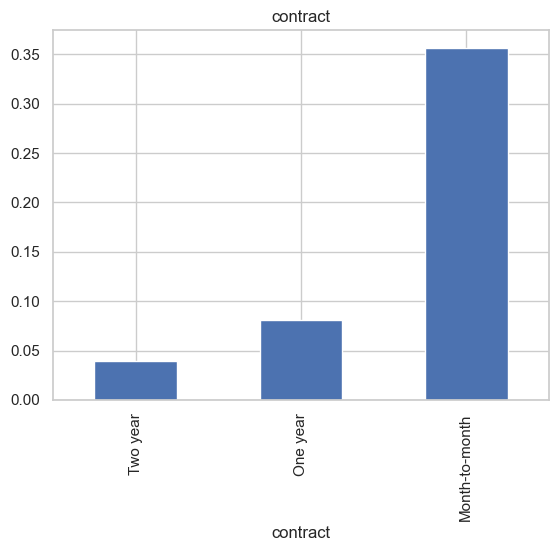

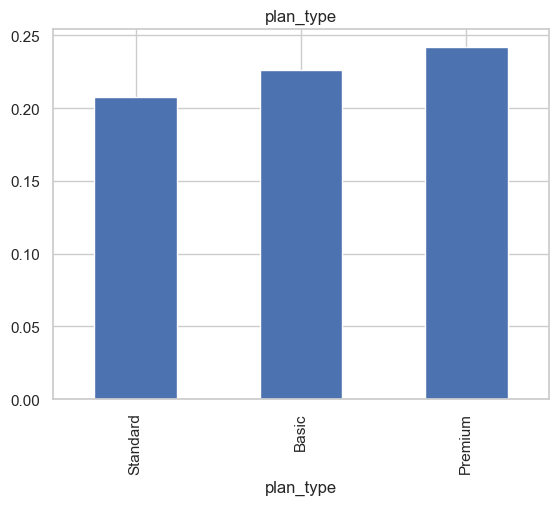

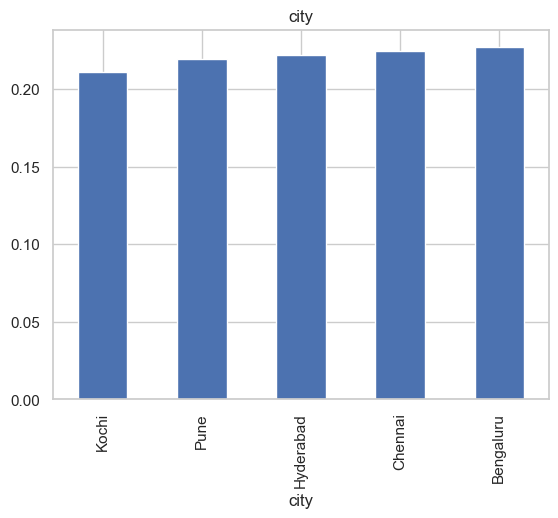

In [51]:
# YOUR CODE HERE
# Hint: df['churned'].mean(); groupby(col)['churned'].mean() for contract/plan_type/city; three barplots
print("Overall:", df.churned.mean().round(3))
for c in ["contract", "plan_type", "city"]:
    df.groupby(c).churned.mean().sort_values().plot.bar(title=c); plt.show()

*Reading:*

### Q2. Which numbers differ between churners and stayers?
For each numeric column: mean for churners vs stayers, Cohen's d, and a test (shuffle or `ttest_ind`). Rank by |d|. **Reading:** which two numbers matter most, and which is noise?

                 churner_mean  stayer_mean  cohen_d       p
tenure_months         18.8257      31.3828  -0.7948  0.0000
total_charges      16753.6553   27957.8079  -0.6479  0.0000
support_calls          1.5768       1.1128   0.4149  0.0000
monthly_charges      900.3196     915.1671  -0.0429  0.1311
age                   45.4277      46.1173  -0.0419  0.1447


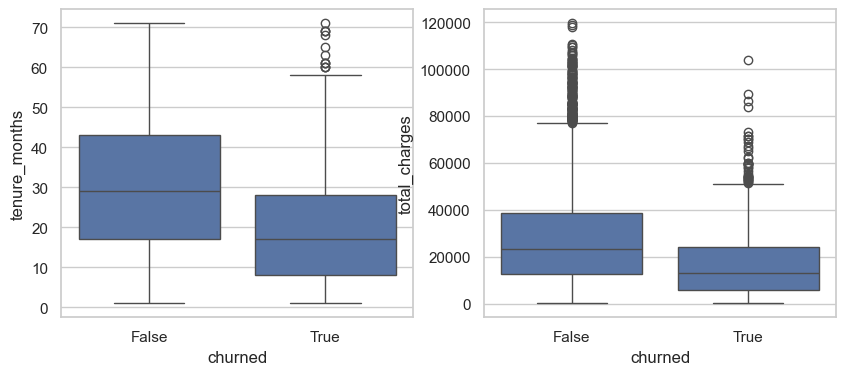

In [52]:
# YOUR CODE HERE
# Hint: for each numeric col: means, Cohen's d, ttest_ind; DataFrame sorted by |d|; two boxplots
num = ["age", "tenure_months", "monthly_charges", "total_charges", "support_calls"]
def stats(c):
    a, b = df.loc[df.churned, c], df.loc[~df.churned, c]
    d = (a.mean() - b.mean()) / np.sqrt((a.var() + b.var()) / 2)
    return pd.Series({"churner_mean": a.mean(), "stayer_mean": b.mean(), "cohen_d": d, "p": ttest_ind(a, b).pvalue})
res = pd.DataFrame({c: stats(c) for c in num}).T
res = res.reindex(res.cohen_d.abs().sort_values(ascending=False).index); print(res.round(4))
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
for a, c in zip(ax, res.index[:2]): sns.boxplot(data=df, x="churned", y=c, ax=a)


*Reading:*

### Q3. Which categories are associated with churn?
`pd.crosstab` per categorical column with churn rate per level, and `chi2_contingency` for the test. **Reading:** which category has the biggest spread in churn rate across its levels?

In [58]:
# YOUR CODE HERE
# Hint: pd.crosstab(df[col], df['churned']); chi2_contingency; churn rate spread per feature
cats = ["city", "gender", "plan_type", "contract", "payment_method", "has_broadband", "has_streaming"]
rows = []
for c in cats:
    ct = pd.crosstab(df[c], df.churned); rate = ct[True] / ct.sum(axis=1)
    rows.append((c, rate.max() - rate.min(), chi2_contingency(ct)[1]))
print(pd.DataFrame(rows, columns=["feature", "spread", "p"]).sort_values("spread", ascending=False).round(4))


          feature  spread       p
3        contract  0.3174  0.0000
4  payment_method  0.0811  0.0000
5   has_broadband  0.0655  0.0000
2       plan_type  0.0342  0.0330
0            city  0.0157  0.9361
6   has_streaming  0.0128  0.2294
1          gender  0.0069  0.5063


*Reading:*

### Q4. Churn by tenure cohort
Bins 0–6, 7–12, 13–24, 25+ months. Bar chart of churn rate per cohort. **Reading:** when is the customer most at risk, and what does that say about onboarding?

cohort
0-6      0.467
7-12     0.321
13-24    0.270
25+      0.136
Name: churned, dtype: float64


<Axes: title={'center': 'Churn rate by tenure cohort'}, xlabel='cohort'>

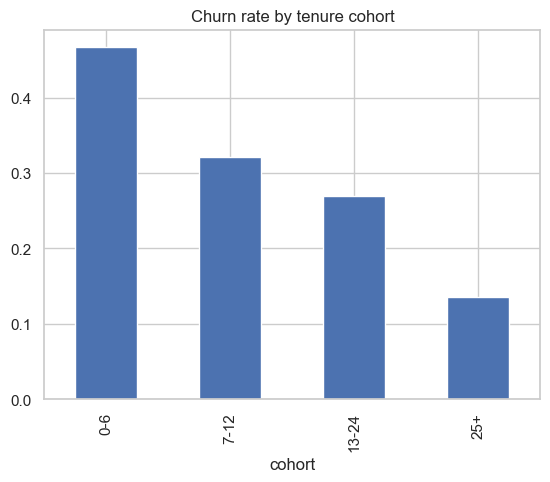

In [ ]:
# YOUR CODE HERE
# Hint: pd.cut(tenure, bins=[0,6,12,24,999]); groupby cohort churn rate; barplot
df["cohort"] = pd.cut(df.tenure_months, [-1, 6, 12, 24, 999] labels=["0-6", "7-12", "13-24", "25+"])
r = df.groupby("cohort", observed=True).churned.mean()
print(r.round(3)); r.plot.bar(title="Churn rate by tenure cohort")


*Reading:*

---
## Session 3 — Q5, Q6, the brief

### Q5. The highest-risk profile, in plain English
Combine the top findings into one segment (e.g. month-to-month + tenure ≤ 6 + 2+ support calls). Report its size, its churn rate, and how many churners it accounts for. **Reading:** is it where the retention budget should go?

In [60]:
# YOUR CODE HERE
# Hint: boolean mask for the segment; size, churn rate, share of all churners
m = (df.contract == "Month-to-month") & (df.tenure_months <= 6) & (df.support_calls >= 2)
print(f"size: {m.sum()} ({m.mean():.1%} of customers) | churn rate: {df.churned[m].mean():.1%} vs overall {df.churned.mean():.1%} | share of all churners: {df.churned[m].sum() / df.churned.sum():.1%}")



size: 213 (3.0% of customers) | churn rate: 62.4% vs overall 22.2% | share of all churners: 8.6%


*Reading:*Minimal code for Q5, using the example segment from the prompt:


It prints the segment's size, its churn rate next to the overall rate, and the share of all churners it captures.

Change the three conditions to match your own findings from Q1 to Q4, for example if your Q3 or Q2 results point to a different top feature. Use your own top findings, not the prompt's example.

For your Reading, the budget goes here if the churn rate is much higher than overall and the segment holds a meaningful share of churners. A segment with a very high rate but only 2% of churners is too small to justify the whole retention budget.

### Q6. Your own question
Options: does churn rise with monthly charges *within* a plan? · are support calls a cause or a symptom (do they rise with tenure)? · payment method × contract interaction · streaming add-on and retention · city differences after controlling for contract mix.

In [61]:
# YOUR CODE HERE
# Hint: your question, your code
df["charge_band"] = df.groupby("plan_type").monthly_charges.transform(lambda s: pd.qcut(s, 3, labels=["low", "mid", "high"]))
print(df.pivot_table(index="plan_type", columns="charge_band", values="churned", observed=True).round(3))


charge_band    low    mid   high
plan_type                       
Basic        0.267  0.224  0.187
Premium      0.281  0.241  0.204
Standard     0.225  0.196  0.202


### The one-page churn brief (for the VP)
Structure: **Situation** (2 lines) → **Three findings**, each with the number → **Recommendation** (where the budget goes, what to change) → **Confidence** (one line: what you'd need to be surer).

> *Your brief here — 250–350 words.*
Written for: the VP Customer, who wants numbers and a decision, not method.

---

**Situation.** TeleConnect lost 22.2% of its customers this year (1,555 of 6,996). Replacing a customer costs four times as much as keeping one, so this is a retention-budget problem. Churn is concentrated in a few identifiable groups, not spread evenly.

**Finding 1: Contract type is the biggest driver.** Month-to-month customers churn at 35.7%, one-year customers at 8.1%, and two-year customers at 3.9%. That is a 9x gap. Plan, city, gender and streaming add-on barely matter: city differs by under 2 points, and price does not separate churners from stayers.

**Finding 2: The first year is the danger zone.** Customers with 0–6 months of tenure churn at 46.7%, versus 13.6% for customers past 24 months. Churners leave after an average of 19 months, against 31 for stayers. Customers who leave do so early, which points to a weak onboarding period.

**Finding 3: Repeat support calls signal a customer about to leave.** Churn rises from 14.6% with zero calls to 35.1% with three calls. Churners average 1.6 calls, against 1.1 for stayers.

**Recommendation.** Put the budget on month-to-month customers in their first 12 months. They are 17% of customers (1,199) but 35% of all churners, and 45% of them leave. Three actions: (1) a structured onboarding program for their first 6 months; (2) an incentive to move to a one-year contract by month 6; (3) a proactive retention call once a customer logs a second support ticket. Do not spend on blanket price cuts or city campaigns, because the data shows no link.

**Confidence.** Medium. These are patterns, not proven causes, and we lack the cost of the offers. A small test of the onboarding and contract offers on one group would show what actually reduces churn.

---

### Cliffhanger
You can describe who churned. The VP asks: "Which of the current 5,400 customers will churn next quarter?" — Module 20, on this exact file.

-> This cliffhanger sets up the next step, moving from describing to predicting. So far you've explained who churned (past customers). The VP now wants a list of which current customers (about 5,400) are likely to leave next quarter, which is a prediction problem.

Module 20 will build a classification model (for example logistic regression or a random forest) on this same file. It will use churned as the target and features like contract, tenure, support calls and payment method, which your Q1–Q5 work already showed matter. The model outputs a churn probability per customer, and the retention team calls the highest-risk ones first.

The findings in your brief tell you which features to feed the model. City, gender and streaming can likely be left out, as your analysis showed no link with churn.